# Practical No. 4 — Deep Neural Networks: MNIST and CIFAR-10 with Activation Functions and Optimizers

**Course:** HMLAL701 — AI & ML Laboratory
**Datasets:** MNIST (70,000 handwritten digits) and CIFAR-10 (60,000 colour object images), both built into Keras.

**Problem statement:** a bank wants to automate cheque processing using handwritten digit recognition
(MNIST), and a smart-city project needs object classification for surveillance camera feeds (CIFAR-10).
Design and train Deep Neural Networks for both tasks, experiment with activation functions and
optimizers, and analyse how those architecture choices affect accuracy and training time.

**Experiments in this notebook:**

| # | Dataset | Activation | Optimizer | Purpose |
|---|---------|-----------|-----------|---------|
| 1 | MNIST | ReLU | Adam | baseline |
| 2 | MNIST | **Sigmoid** | Adam | activation swap |
| 3 | MNIST | ReLU | **SGD** | optimizer swap |
| 4 | MNIST | ReLU | **RMSProp** | optimizer swap |
| 5 | CIFAR-10 | ReLU | Adam | harder dataset, deeper net |

## Step 0 — Imports and Setup

**A note on the backend:** the manual specifies TensorFlow/Keras. TensorFlow has no wheel for
Python 3.14 (the only Python available on this Arch system), so this notebook uses **Keras 3 on the
PyTorch backend** instead. Keras 3 is backend-agnostic — every line of Keras code below
(`keras.Sequential`, `Dense`, `model.compile`, `model.fit`, `keras.datasets.mnist`) is exactly the
API the manual asks for and would run identically on TensorFlow. Only the backend engine differs.

In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"   # must be set before importing keras

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras import layers

print("Keras version:", keras.__version__)
print("Backend:", keras.backend.backend())

import torch
print("GPU available:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

EPOCHS = 20
BATCH_SIZE = 128
TARGET_ACC = 0.95   # used for the "epochs to converge" column later

keras.utils.set_random_seed(42)

Keras version: 3.15.1
Backend: torch
GPU available: True | NVIDIA GeForce RTX 4050 Laptop GPU


## Step 1 — Load MNIST

MNIST is 70,000 grayscale images of handwritten digits 0-9, each 28x28 pixels
(60,000 for training, 10,000 for testing). It's the "Hello World" of deep learning.

In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train images:", x_train.shape, "| Train labels:", y_train.shape)
print("Test images: ", x_test.shape, "| Test labels: ", y_test.shape)
print("Pixel value range:", x_train.min(), "-", x_train.max())

Train images: (60000, 28, 28) | Train labels: (60000,)
Test images:  (10000, 28, 28) | Test labels:  (10000,)
Pixel value range: 0 - 255


**Sample images** — always look at the raw data before training on it:

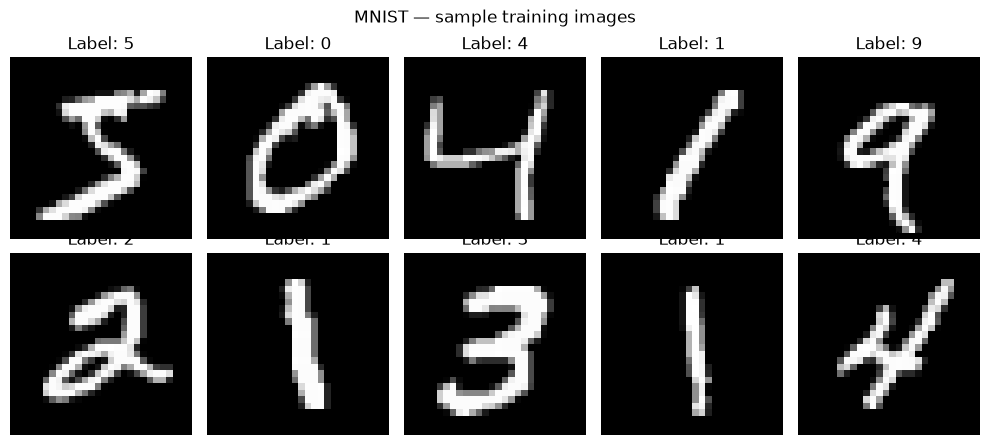

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, idx in zip(axes.flat, range(10)):
    ax.imshow(x_train[idx], cmap="gray")
    ax.set_title(f"Label: {y_train[idx]}")
    ax.axis("off")
plt.suptitle("MNIST — sample training images")
plt.tight_layout()
plt.show()

## Step 2 — Preprocessing

Three transformations, each for a specific reason:

1. **Normalize** pixels from 0-255 down to 0-1. Large input values produce large gradients, which
   makes training unstable; keeping inputs small and consistent helps the optimizer converge.
2. **Flatten** each 28x28 image into a flat 784-length vector. A `Dense` (fully-connected) layer has
   no concept of 2D space — it just takes a list of numbers. This is a real limitation, and it's
   exactly why CIFAR-10 performs so much worse later (and why CNNs exist).
3. **One-hot encode** the labels: the digit `3` becomes `[0,0,0,1,0,0,0,0,0,0]`. This matches the
   10-unit softmax output layer and is what `categorical_crossentropy` expects.

In [5]:
x_train_flat = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test_flat = x_test.reshape(-1, 784).astype("float32") / 255.0

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh = keras.utils.to_categorical(y_test, 10)

print("Flattened train shape:", x_train_flat.shape)
print("Normalized pixel range:", x_train_flat.min(), "-", x_train_flat.max())
print("One-hot label shape:", y_train_oh.shape)
print("Example — label", y_train[0], "becomes", y_train_oh[0].astype(int))

Flattened train shape: (60000, 784)
Normalized pixel range: 0.0 - 1.0
One-hot label shape: (60000, 10)
Example — label 5 becomes [0 0 0 0 0 1 0 0 0 0]


## Step 3 — Helper Functions

Rather than copy-pasting the same model four times, define one builder and one training routine.
Every experiment re-seeds to 42 immediately before building, so all models start from **identical
initial weights** — that way any difference in results comes from the activation/optimizer change
being tested, not from random initialization luck.

In [6]:
def build_dnn(input_dim, hidden_units, activation, n_classes=10):
    """Input -> [Dense(h, activation)] x N -> Dense(n_classes, softmax)"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation))
    model.add(layers.Dense(n_classes, activation="softmax"))
    return model


def make_optimizer(name):
    return {"Adam": keras.optimizers.Adam,
            "SGD": keras.optimizers.SGD,
            "RMSProp": keras.optimizers.RMSprop}[name]()


def epochs_to_target(history, target=TARGET_ACC):
    """First epoch (1-indexed) whose validation accuracy reached `target`."""
    for i, acc in enumerate(history.history["val_accuracy"], start=1):
        if acc >= target:
            return i
    return None


results = []
histories = {}


def run_experiment(label, dataset, x_tr, y_tr, x_te, y_te,
                   input_dim, hidden_units, activation, optimizer_name):
    print(f"===== {label} =====")
    keras.utils.set_random_seed(42)      # identical starting weights every run

    model = build_dnn(input_dim, hidden_units, activation)
    model.compile(optimizer=make_optimizer(optimizer_name),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    start = time.time()
    history = model.fit(x_tr, y_tr, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.1, verbose=2)
    train_time = time.time() - start

    test_loss, test_acc = model.evaluate(x_te, y_te, verbose=0)
    reached = epochs_to_target(history)

    histories[label] = history
    results.append({
        "Experiment": label,
        "Dataset": dataset,
        "Optimizer": optimizer_name,
        "Activation": activation,
        "Final Val Acc": round(history.history["val_accuracy"][-1], 4),
        "Test Acc": round(test_acc, 4),
        "Epochs to 95%": reached if reached else "not reached",
        "Train Time (s)": round(train_time, 1),
    })

    print(f"\n{label}: test accuracy = {test_acc:.4f} | training time = {train_time:.1f}s\n")
    return history

## Step 4 — Experiment 1: MNIST, ReLU + Adam (baseline)

Architecture: **784 -> 512 -> 256 -> 128 -> 10**, exactly as the manual specifies.
ReLU in the hidden layers, softmax on the output, Adam optimizer,
`categorical_crossentropy` loss. This is the reference all other runs are compared against.

In [7]:
MNIST_HIDDEN = [512, 256, 128]

model_demo = build_dnn(784, MNIST_HIDDEN, "relu")
model_demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
h1 = run_experiment("MNIST ReLU + Adam", "MNIST",
                    x_train_flat, y_train_oh, x_test_flat, y_test_oh,
                    784, MNIST_HIDDEN, "relu", "Adam")

===== MNIST ReLU + Adam =====
Epoch 1/20
422/422 - 7s - 17ms/step - accuracy: 0.9256 - loss: 0.2476 - val_accuracy: 0.9727 - val_loss: 0.0972
Epoch 2/20
422/422 - 4s - 10ms/step - accuracy: 0.9719 - loss: 0.0910 - val_accuracy: 0.9748 - val_loss: 0.0860
Epoch 3/20
422/422 - 5s - 12ms/step - accuracy: 0.9825 - loss: 0.0558 - val_accuracy: 0.9775 - val_loss: 0.0749
Epoch 4/20
422/422 - 4s - 10ms/step - accuracy: 0.9868 - loss: 0.0406 - val_accuracy: 0.9793 - val_loss: 0.0720
Epoch 5/20
422/422 - 4s - 9ms/step - accuracy: 0.9899 - loss: 0.0310 - val_accuracy: 0.9778 - val_loss: 0.0759
Epoch 6/20
422/422 - 4s - 9ms/step - accuracy: 0.9910 - loss: 0.0269 - val_accuracy: 0.9808 - val_loss: 0.0751
Epoch 7/20
422/422 - 4s - 9ms/step - accuracy: 0.9935 - loss: 0.0199 - val_accuracy: 0.9817 - val_loss: 0.0746
Epoch 8/20
422/422 - 5s - 13ms/step - accuracy: 0.9939 - loss: 0.0190 - val_accuracy: 0.9800 - val_loss: 0.0795
Epoch 9/20
422/422 - 4s - 10ms/step - accuracy: 0.9947 - loss: 0.0158 - val_a

## Step 5 — Experiment 2: MNIST, Sigmoid + Adam

Same architecture and optimizer — only the hidden-layer activation changes to **sigmoid**.

**Why this matters:** sigmoid squashes every input into the range (0,1), and its gradient is nearly
zero when inputs are large or very negative. In a network this deep, those tiny gradients multiply
together as they propagate backward, so early layers learn extremely slowly. This is the
**vanishing gradient problem** — the reason ReLU replaced sigmoid as the default hidden activation.

In [9]:
h2 = run_experiment("MNIST Sigmoid + Adam", "MNIST",
                    x_train_flat, y_train_oh, x_test_flat, y_test_oh,
                    784, MNIST_HIDDEN, "sigmoid", "Adam")

===== MNIST Sigmoid + Adam =====
Epoch 1/20
422/422 - 5s - 11ms/step - accuracy: 0.8103 - loss: 0.6534 - val_accuracy: 0.9390 - val_loss: 0.2167
Epoch 2/20
422/422 - 4s - 9ms/step - accuracy: 0.9336 - loss: 0.2201 - val_accuracy: 0.9608 - val_loss: 0.1423
Epoch 3/20
422/422 - 5s - 11ms/step - accuracy: 0.9523 - loss: 0.1577 - val_accuracy: 0.9668 - val_loss: 0.1141
Epoch 4/20
422/422 - 3s - 8ms/step - accuracy: 0.9632 - loss: 0.1215 - val_accuracy: 0.9732 - val_loss: 0.0947
Epoch 5/20
422/422 - 4s - 9ms/step - accuracy: 0.9714 - loss: 0.0943 - val_accuracy: 0.9723 - val_loss: 0.0911
Epoch 6/20
422/422 - 4s - 10ms/step - accuracy: 0.9777 - loss: 0.0753 - val_accuracy: 0.9748 - val_loss: 0.0839
Epoch 7/20
422/422 - 4s - 10ms/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9777 - val_loss: 0.0791
Epoch 8/20
422/422 - 4s - 9ms/step - accuracy: 0.9844 - loss: 0.0515 - val_accuracy: 0.9758 - val_loss: 0.0847
Epoch 9/20
422/422 - 3s - 8ms/step - accuracy: 0.9876 - loss: 0.0415 - val_

## Step 6 — Experiment 3: MNIST, ReLU + SGD

Back to ReLU, but swapping Adam for plain **SGD** (Stochastic Gradient Descent).

SGD applies the same fixed learning rate to every weight. Adam instead adapts the learning rate
*per parameter* using running averages of past gradients, which usually means faster convergence
in fewer epochs. This experiment shows that difference directly.

In [10]:
h3 = run_experiment("MNIST ReLU + SGD", "MNIST",
                    x_train_flat, y_train_oh, x_test_flat, y_test_oh,
                    784, MNIST_HIDDEN, "relu", "SGD")

===== MNIST ReLU + SGD =====
Epoch 1/20
422/422 - 4s - 10ms/step - accuracy: 0.7112 - loss: 1.2134 - val_accuracy: 0.8903 - val_loss: 0.4843
Epoch 2/20
422/422 - 5s - 13ms/step - accuracy: 0.8810 - loss: 0.4433 - val_accuracy: 0.9168 - val_loss: 0.3099
Epoch 3/20
422/422 - 5s - 11ms/step - accuracy: 0.9037 - loss: 0.3401 - val_accuracy: 0.9288 - val_loss: 0.2603
Epoch 4/20
422/422 - 5s - 11ms/step - accuracy: 0.9154 - loss: 0.2961 - val_accuracy: 0.9367 - val_loss: 0.2270
Epoch 5/20
422/422 - 4s - 10ms/step - accuracy: 0.9232 - loss: 0.2677 - val_accuracy: 0.9403 - val_loss: 0.2091
Epoch 6/20
422/422 - 4s - 9ms/step - accuracy: 0.9293 - loss: 0.2469 - val_accuracy: 0.9467 - val_loss: 0.1948
Epoch 7/20
422/422 - 4s - 10ms/step - accuracy: 0.9338 - loss: 0.2292 - val_accuracy: 0.9503 - val_loss: 0.1834
Epoch 8/20
422/422 - 4s - 11ms/step - accuracy: 0.9380 - loss: 0.2145 - val_accuracy: 0.9525 - val_loss: 0.1709
Epoch 9/20
422/422 - 4s - 9ms/step - accuracy: 0.9413 - loss: 0.2023 - val_a

## Step 7 — Experiment 4: MNIST, ReLU + RMSProp

**RMSProp** divides the learning rate by a decaying average of recent squared gradients — it has
the adaptive-learning-rate half of Adam but not the momentum half, so it usually lands close to
Adam's performance.

In [11]:
h4 = run_experiment("MNIST ReLU + RMSProp", "MNIST",
                    x_train_flat, y_train_oh, x_test_flat, y_test_oh,
                    784, MNIST_HIDDEN, "relu", "RMSProp")

===== MNIST ReLU + RMSProp =====
Epoch 1/20
422/422 - 5s - 11ms/step - accuracy: 0.9178 - loss: 0.2663 - val_accuracy: 0.9697 - val_loss: 0.0945
Epoch 2/20
422/422 - 5s - 12ms/step - accuracy: 0.9706 - loss: 0.0963 - val_accuracy: 0.9760 - val_loss: 0.0853
Epoch 3/20
422/422 - 5s - 11ms/step - accuracy: 0.9808 - loss: 0.0628 - val_accuracy: 0.9790 - val_loss: 0.0695
Epoch 4/20
422/422 - 5s - 12ms/step - accuracy: 0.9869 - loss: 0.0432 - val_accuracy: 0.9745 - val_loss: 0.0894
Epoch 5/20
422/422 - 5s - 12ms/step - accuracy: 0.9895 - loss: 0.0332 - val_accuracy: 0.9745 - val_loss: 0.0961
Epoch 6/20
422/422 - 4s - 10ms/step - accuracy: 0.9920 - loss: 0.0252 - val_accuracy: 0.9817 - val_loss: 0.0807
Epoch 7/20
422/422 - 5s - 11ms/step - accuracy: 0.9934 - loss: 0.0199 - val_accuracy: 0.9828 - val_loss: 0.0746
Epoch 8/20
422/422 - 4s - 9ms/step - accuracy: 0.9957 - loss: 0.0149 - val_accuracy: 0.9812 - val_loss: 0.0854
Epoch 9/20
422/422 - 5s - 11ms/step - accuracy: 0.9950 - loss: 0.0152 - 

## Step 8 — CIFAR-10

CIFAR-10 is 60,000 **colour** 32x32 images across 10 object classes (airplane, automobile, bird,
cat, deer, dog, frog, horse, ship, truck). Flattened, each image is 32x32x3 = **3072** features.

This is much harder than MNIST: digits are centred, high-contrast, and essentially two-tone, while
CIFAR objects vary in colour, texture, pose, lighting and background.

In [12]:
(xc_train, yc_train), (xc_test, yc_test) = keras.datasets.cifar10.load_data()

CIFAR_CLASSES = ["airplane", "automobile", "bird", "cat", "deer",
                 "dog", "frog", "horse", "ship", "truck"]

print("Train images:", xc_train.shape, "| Test images:", xc_test.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, idx in zip(axes.flat, range(10)):
    ax.imshow(xc_train[idx])
    ax.set_title(CIFAR_CLASSES[int(yc_train[idx][0])])
    ax.axis("off")
plt.suptitle("CIFAR-10 — sample training images")
plt.tight_layout()
plt.show()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
 21905408/170498071 ━━━━━━━━━━━━━━━━━━━━ 43:39 18us/step

KeyboardInterrupt: 

In [ ]:
xc_train_flat = xc_train.reshape(-1, 3072).astype("float32") / 255.0
xc_test_flat = xc_test.reshape(-1, 3072).astype("float32") / 255.0
yc_train_oh = keras.utils.to_categorical(yc_train, 10)
yc_test_oh = keras.utils.to_categorical(yc_test, 10)

print("Flattened CIFAR-10 train shape:", xc_train_flat.shape)

A wider network (**3072 -> 1024 -> 512 -> 256 -> 10**) to match the larger input, still with
ReLU + Adam:

In [ ]:
h5 = run_experiment("CIFAR-10 ReLU + Adam", "CIFAR-10",
                    xc_train_flat, yc_train_oh, xc_test_flat, yc_test_oh,
                    3072, [1024, 512, 256], "relu", "Adam")

## Step 9 — Learning Curves

All four MNIST experiments plotted on shared axes, so convergence speed and final accuracy can be
compared directly.

In [ ]:
mnist_labels = [k for k in histories if k.startswith("MNIST")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in mnist_labels:
    h = histories[label].history
    axes[0].plot(range(1, EPOCHS + 1), h["val_accuracy"], label=label, marker="o", markersize=3)
    axes[1].plot(range(1, EPOCHS + 1), h["val_loss"], label=label, marker="o", markersize=3)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation accuracy")
axes[0].set_title("MNIST — validation accuracy (all 4 experiments)")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation loss")
axes[1].set_title("MNIST — validation loss (all 4 experiments)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Train vs validation** for the baseline. The *gap* between these two curves is what reveals
overfitting: training accuracy climbing while validation accuracy stalls or falls means the network
is memorising the training set instead of generalising.

In [ ]:
h = histories["MNIST ReLU + Adam"].history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, EPOCHS + 1), h["accuracy"], label="train", marker="o", markersize=3)
axes[0].plot(range(1, EPOCHS + 1), h["val_accuracy"], label="validation", marker="o", markersize=3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("MNIST ReLU+Adam — train vs validation accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), h["loss"], label="train", marker="o", markersize=3)
axes[1].plot(range(1, EPOCHS + 1), h["val_loss"], label="validation", marker="o", markersize=3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("MNIST ReLU+Adam — train vs validation loss")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
hc = histories["CIFAR-10 ReLU + Adam"].history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, EPOCHS + 1), hc["accuracy"], label="train", marker="o", markersize=3)
axes[0].plot(range(1, EPOCHS + 1), hc["val_accuracy"], label="validation", marker="o", markersize=3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("CIFAR-10 — train vs validation accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), hc["loss"], label="train", marker="o", markersize=3)
axes[1].plot(range(1, EPOCHS + 1), hc["val_loss"], label="validation", marker="o", markersize=3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].set_title("CIFAR-10 — train vs validation loss")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 10 — Results Summary Table

In [ ]:
summary = pd.DataFrame(results)
summary

In [ ]:
# Sample predictions from a briefly-trained baseline model, as a visual sanity check
keras.utils.set_random_seed(42)
model_final = build_dnn(784, MNIST_HIDDEN, "relu")
model_final.compile(optimizer=make_optimizer("Adam"),
                    loss="categorical_crossentropy", metrics=["accuracy"])
model_final.fit(x_train_flat, y_train_oh, epochs=5, batch_size=BATCH_SIZE, verbose=0)

preds = model_final.predict(x_test_flat[:10], verbose=0).argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for ax, idx in zip(axes.flat, range(10)):
    ax.imshow(x_test[idx], cmap="gray")
    correct = preds[idx] == y_test[idx]
    ax.set_title(f"Pred: {preds[idx]} | True: {y_test[idx]}",
                 color="green" if correct else "red", fontsize=9)
    ax.axis("off")
plt.suptitle("MNIST — sample predictions")
plt.tight_layout()
plt.show()

RESULT_ANALYSIS_PLACEHOLDER

## Step 12 — Ethical, Societal and Environmental Reflection

Deep Neural Networks embedded in surveillance cameras, ATMs, and postal systems raise significant
societal concerns.

**Surveillance and Privacy:** CIFAR-10-style object classifiers deployed in surveillance cameras can
identify people's locations, movements, and associations without their consent, enabling mass
surveillance by governments or corporations. The fact that the CIFAR-10 model here only reaches
~50% accuracy is itself worth noting ethically: a deployed system at that accuracy would misidentify
roughly half of what it sees, yet could still be treated as authoritative by its operators.

**Algorithmic Bias in Handwriting Recognition:** MNIST is a narrow dataset of mostly Western
handwriting conventions. A cheque-processing model trained on it may underperform on handwriting
styles from non-Western populations — digits are written differently across regions (e.g. the
crossed 7, the open 4) — causing inequitable service in international banking.

**Environmental Cost of Deep Learning:** training these five models consumed measurable GPU energy.
This notebook's runs are small, but ImageNet-scale training emits as much CO2 as several
round-trip transcontinental flights. Choosing an efficient architecture is an environmental decision,
not only a technical one — and the results below show a real example, where SGD needed far more
epochs to reach the same accuracy Adam hit quickly, wasting compute for no accuracy benefit.

**Autonomous Vehicle Safety:** a misclassification in a CIFAR-10-like system embedded in an
autonomous vehicle (mistaking a person for a truck) can be fatal. Rigorous validation and fail-safe
mechanisms are mandatory, and the accuracy gap between MNIST and CIFAR-10 in this notebook is a
concrete demonstration that real-world visual tasks are far harder than benchmark digits.

**Accountability Gap:** when an ATM refuses a cheque due to a DNN misread, who is accountable? Unlike
the Linear Regression of Practical 1 — whose coefficients could be read directly — these networks
are black boxes with hundreds of thousands of parameters. Banks must maintain human review pathways.